# 04 – Datenanalyse & Beantwortung der Fragestellungen

**Projekt:** Polymarket Reddit Sentiment  
**Kurs:** Data Wrangling & Engineering (FHNW)

## Fragestellungen

1. **F1:** Stimmt das Reddit-Sentiment mit der Polymarket-Marktwahrscheinlichkeit überein?
2. **F2:** Unterscheidet sich das Sentiment signifikant zwischen verschiedenen Subreddits?
3. **F3:** Gibt es zeitliche Muster im Sentiment? (z.B. Stimmungsschwankungen über die Woche)

---

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src import reddit, polymarket, sentiment

print('Libraries geladen.')

Libraries geladen.


In [2]:
import os

# posts_per_market.csv (Bulk-Run, 690 Posts, pro Markt) bevorzugen
POSTS_BULK = '../data/posts_per_market.csv'
POSTS_OLD  = '../data/reddit_clean.csv'

if os.path.exists(POSTS_BULK):
    posts_df = pd.read_csv(POSTS_BULK, parse_dates=['created_utc'])
    # sentiment_label ableiten falls nicht vorhanden
    if 'sentiment_label' not in posts_df.columns:
        posts_df['sentiment_label'] = posts_df['compound'].apply(
            lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
        )
    print(f'Posts geladen (Bulk-Run): {posts_df.shape}')
    print(f'Maerkte: {posts_df["market_question"].nunique()}')
    print(f'Subreddits: {sorted(posts_df["subreddit"].unique())}')
elif os.path.exists(POSTS_OLD):
    posts_df = pd.read_csv(POSTS_OLD, parse_dates=['created_utc'])
    if 'sentiment_label' not in posts_df.columns:
        posts_df['sentiment_label'] = posts_df['compound'].apply(
            lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
        )
    print(f'Posts geladen (reddit_clean.csv): {posts_df.shape}')
else:
    from src import reddit as r
    raw = r.get_posts('Bitcoin', ['investing','stocks','worldnews','CryptoCurrency'], 100)
    posts_df = sentiment.analyze(raw)
    posts_df['sentiment_label'] = posts_df['compound'].apply(
        lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
    )
    print(f'Posts live geladen: {posts_df.shape}')

# Polymarket-Daten laden
if os.path.exists('../data/polymarket_clean.csv'):
    markets_df = pd.read_csv('../data/polymarket_clean.csv')
    print(f'Polymarket (bereinigt): {markets_df.shape}')
else:
    markets_df = pd.DataFrame()


Posts geladen (Bulk-Run): (750, 9)
Maerkte: 30
Subreddits: ['Economics', 'geopolitics', 'investing', 'news', 'politics', 'stocks', 'worldnews']
Polymarket (bereinigt): (2, 6)


---
## F1: Korrelation zwischen Reddit-Sentiment und Polymarket-Wahrscheinlichkeit

### Methode
Statt alle Posts pauschal zu vergleichen, gehen wir **pro Markt** vor:

```
Für jeden Polymarket-Markt:
  1. Keywords aus der Frage extrahieren
  2. Reddit gezielt nach diesen Keywords durchsuchen
  3. Sentiment der gefundenen Posts berechnen
  4. Paar speichern: (Markt-Wahrscheinlichkeit, Ø Reddit-Sentiment)

Danach:
  → Pearson-Korrelation (lineare Beziehung)
  → Spearman-Korrelation (Rangkorrelation, robust gegen Ausreisser)
  → Scatter-Plot mit Regressionslinie
```

In [3]:
import time
import re

# ── Konfiguration ─────────────────────────────────────────────────────────────
MAX_MARKETS        = 10     # Weniger Märkte, dafür mehr Tiefe pro Markt
POSTS_PER_MARKET   = 30     # Mehr Posts für bessere Stichprobe
SEMANTIC_THRESHOLD = 0.20   # Mindest-Ähnlichkeit zur Markt-Frage (sentence-transformers)
SUBREDDITS = ["politics", "worldnews", "stocks", "investing", "news",
              "Economics", "geopolitics", "collapse", "Futurology"]

STOPWORDS = {
    "will", "would", "could", "should", "has", "have", "been", "the",
    "and", "are", "for", "was", "not", "with", "this", "that", "from",
    "its", "which", "when", "who", "how", "what", "why", "does", "did",
    "any", "all", "into", "over", "about", "than", "more", "first",
    "2024", "2025", "2026", "year", "end", "hit", "win", "get", "per",
}

def extract_keywords(question: str, n: int = 4) -> str:
    """Extrahiert die n wichtigsten Wörter aus einer Markt-Frage."""
    words = re.findall(r"[A-Za-z]{4,}", question)
    keywords = [w for w in words if w.lower() not in STOPWORDS]
    return " ".join(keywords[:n]) if keywords else question[:50]


# ── Demo-Datensatz: 40 Polymarket-Märkte ─────────────────────────────────────
SAMPLE_DATA = [
    # US Politik
    {"question": "Will Trump be impeached in 2025?",              "probability": 0.08,  "category": "Politics"},
    {"question": "Will there be a US federal shutdown in 2025?",  "probability": 0.35,  "category": "Politics"},
    {"question": "Will the US raise the debt ceiling in 2025?",   "probability": 0.82,  "category": "Politics"},
    {"question": "Will Biden pardon Trump?",                       "probability": 0.04,  "category": "Politics"},
    {"question": "Will a third party win a Senate seat in 2025?", "probability": 0.12,  "category": "Politics"},
    {"question": "Will Kamala Harris run for president again?",   "probability": 0.28,  "category": "Politics"},
    # Wirtschaft
    {"question": "Will the US enter a recession in 2025?",       "probability": 0.31,  "category": "Economy"},
    {"question": "Will the Fed cut rates in 2025?",               "probability": 0.74,  "category": "Economy"},
    {"question": "Will inflation stay above 3% in 2025?",         "probability": 0.40,  "category": "Economy"},
    {"question": "Will gold exceed $3000 per ounce?",             "probability": 0.68,  "category": "Economy"},
    {"question": "Will oil fall below $60 per barrel?",           "probability": 0.22,  "category": "Economy"},
    {"question": "Will the S&P 500 reach 6500?",                  "probability": 0.55,  "category": "Economy"},
    # Krypto
    {"question": "Will Bitcoin reach $150000 in 2025?",           "probability": 0.38,  "category": "Crypto"},
    {"question": "Will Ethereum exceed $5000?",                   "probability": 0.29,  "category": "Crypto"},
    {"question": "Will a Bitcoin ETF reach $100B AUM?",           "probability": 0.45,  "category": "Crypto"},
    {"question": "Will Solana hit $400?",                         "probability": 0.21,  "category": "Crypto"},
    {"question": "Will Bitcoin market cap exceed $3 trillion?",   "probability": 0.33,  "category": "Crypto"},
    # Tech
    {"question": "Will Apple release AR glasses in 2025?",        "probability": 0.14,  "category": "Tech"},
    {"question": "Will OpenAI IPO in 2025?",                      "probability": 0.19,  "category": "Tech"},
    {"question": "Will Nvidia stock double from 2024 peak?",      "probability": 0.24,  "category": "Tech"},
    {"question": "Will Tesla release a $25000 car?",              "probability": 0.16,  "category": "Tech"},
    {"question": "Will a major AI regulation pass in the EU?",    "probability": 0.58,  "category": "Tech"},
    # Geopolitik
    {"question": "Will there be a ceasefire in Ukraine in 2025?", "probability": 0.47,  "category": "Geopolitics"},
    {"question": "Will China invade Taiwan by 2026?",             "probability": 0.07,  "category": "Geopolitics"},
    {"question": "Will North Korea conduct nuclear test in 2025?","probability": 0.13,  "category": "Geopolitics"},
    {"question": "Will NATO expand further in 2025?",             "probability": 0.35,  "category": "Geopolitics"},
    {"question": "Will Iran produce nuclear weapon in 2025?",     "probability": 0.06,  "category": "Geopolitics"},
    {"question": "Will US and Russia normalize relations?",        "probability": 0.23,  "category": "Geopolitics"},
    # Klima & Energie
    {"question": "Will 2025 be the hottest year on record?",      "probability": 0.61,  "category": "Climate"},
    {"question": "Will the US rejoin Paris Agreement?",           "probability": 0.11,  "category": "Climate"},
    {"question": "Will solar reach 20% of US energy mix?",        "probability": 0.42,  "category": "Climate"},
    {"question": "Will a major hurricane hit New York in 2025?",  "probability": 0.09,  "category": "Climate"},
    # Sport & Kultur
    {"question": "Will Taylor Swift win Album of the Year 2025?", "probability": 0.32,  "category": "Culture"},
    {"question": "Will the NFL expand to 18 games?",              "probability": 0.27,  "category": "Culture"},
    {"question": "Will a new Lord of the Rings film be announced?","probability": 0.18, "category": "Culture"},
    # Gesundheit
    {"question": "Will a new COVID variant cause WHO alert?",     "probability": 0.24,  "category": "Health"},
    {"question": "Will weight-loss drugs exceed $50B in sales?",  "probability": 0.63,  "category": "Health"},
    {"question": "Will the US ban TikTok?",                       "probability": 0.41,  "category": "Politics"},
    {"question": "Will Elon Musk remain Twitter/X CEO in 2025?",  "probability": 0.71,  "category": "Tech"},
    {"question": "Will SpaceX land humans on Mars by 2030?",      "probability": 0.09,  "category": "Tech"},
]

# Polymarket-API versuchen, sonst Demo-Datensatz
try:
    _live = polymarket.get_markets(limit=MAX_MARKETS)
    if not _live.empty and 'probability' in _live.columns:
        sample_markets = _live.head(MAX_MARKETS).reset_index(drop=True)
        print(f'Polymarket live: {len(sample_markets)} Märkte geladen.')
    else:
        raise ValueError("Leere API-Antwort")
except Exception as _e:
    print(f'Polymarket API nicht verfügbar -> Demo-Datensatz wird verwendet.')
    sample_markets = pd.DataFrame(SAMPLE_DATA).head(MAX_MARKETS)
    print(f'Demo-Datensatz: {len(sample_markets)} Märkte')

print(f'\nKonfiguration:')
print(f'  Märkte:             {len(sample_markets)}')
print(f'  Posts/Markt:        {POSTS_PER_MARKET}')
print(f'  Sem. Threshold:     {SEMANTIC_THRESHOLD}')
print(f'  Subreddits:         {SUBREDDITS}')
sample_markets.head(5)


Polymarket API nicht verfügbar -> Demo-Datensatz wird verwendet.
Demo-Datensatz: 10 Märkte

Konfiguration:
  Märkte:             10
  Posts/Markt:        30
  Sem. Threshold:     0.2
  Subreddits:         ['politics', 'worldnews', 'stocks', 'investing', 'news', 'Economics', 'geopolitics', 'collapse', 'Futurology']


,question,probability,category
0,Will Trump be impeached in 2025?,0.08,Politics
1,Will there be a US federal shutdown in 2025?,0.35,Politics
2,Will the US raise the debt ceiling in 2025?,0.82,Politics
3,Will Biden pardon Trump?,0.04,Politics
4,Will a third party win a Senate seat in 2025?,0.12,Politics


In [4]:
# ── Sentiment-Modell Konfiguration ───────────────────────────────────────────
#
# Modell wählen:
#   sentiment.MODEL_VADER           – schnell, kein Download (~sofort)
#   sentiment.MODEL_FINBERT         – Finanztexte, ~440 MB, pip install transformers torch
#   sentiment.MODEL_ROBERTA         – Social Media, ~500 MB, pip install transformers torch
#
SENTIMENT_MODEL  = sentiment.MODEL_FINBERT  # FinBERT: domänenspezifisch für Finanztexte
INCLUDE_COMMENTS = True                     # Kommentare zu Posts mitholen
COMMENT_LIMIT    = 10                       # Kommentare pro Post

print(f'Sentiment-Modell : {SENTIMENT_MODEL}')
print(f'Mit Kommentaren  : {INCLUDE_COMMENTS} (max. {COMMENT_LIMIT} pro Post)')
print(f'Sem. Filterung   : threshold={SEMANTIC_THRESHOLD} (sentence-transformers)')

try:
    import transformers
    print(f'transformers {transformers.__version__} verfügbar.')
except ImportError:
    print('FEHLER: pip install transformers torch')

try:
    import sentence_transformers
    print(f'sentence-transformers {sentence_transformers.__version__} verfügbar.')
except ImportError:
    print('FEHLER: pip install sentence-transformers')


Sentiment-Modell : finbert
Mit Kommentaren  : True (max. 10 pro Post)
Sem. Filterung   : threshold=0.2 (sentence-transformers)


transformers 5.2.0 verfügbar.
FEHLER: pip install sentence-transformers


In [5]:
# ── Pro Markt: Posts holen, semantisch filtern & Sentiment berechnen ──────────
import os

CSV_PATH = '../data/correlation_pairs_bulk.csv'  # 30 Märkte, RoBERTa (vollständiger Datensatz)

if os.path.exists(CSV_PATH):
    pairs_df = pd.read_csv(CSV_PATH)
    print(f'Lade gespeicherte Paare: {len(pairs_df)} Maerkte aus {CSV_PATH}')
    print(pairs_df[['question','probability','mean_compound','n_posts','category']].to_string(index=False))
else:
    pairs = []

    for i, row in sample_markets.iterrows():
        question = row['question']
        prob     = row['probability']
        category = row.get('category', 'Unknown')
        keywords = extract_keywords(question, n=4)

        try:
            # 1. Reddit-Posts per Keyword-Suche holen
            raw = reddit.get_posts(
                keywords,
                SUBREDDITS,
                POSTS_PER_MARKET,
                include_comments=INCLUDE_COMMENTS,
                comment_limit=COMMENT_LIMIT,
            )
            if raw.empty:
                print(f'  SKIP [{keywords}] keine Posts')
                continue

            # 2. Semantische Filterung: nur Posts die zur Frage passen
            raw = sentiment.semantic_filter(raw, question, threshold=SEMANTIC_THRESHOLD)
            if len(raw) < 3:
                print(f'  SKIP [{keywords}] zu wenige relevante Posts nach Filterung')
                continue

            n_posts    = (raw['content_type'] == 'post').sum()    if 'content_type' in raw.columns else len(raw)
            n_comments = (raw['content_type'] == 'comment').sum() if 'content_type' in raw.columns else 0

            # 3. FinBERT Sentiment
            scored = sentiment.analyze(raw, model=SENTIMENT_MODEL)
            mean_s = scored['compound'].mean()
            weights = np.log1p(scored['score'].clip(lower=0).fillna(0).values)
            weighted_s = np.average(scored['compound'].values, weights=weights) if weights.sum() > 0 else mean_s

            pairs.append({
                'question':          question,
                'probability':       prob,
                'mean_compound':     mean_s,
                'weighted_compound': weighted_s,
                'n_posts':           n_posts,
                'n_comments':        n_comments,
                'n_total':           len(scored),
                'keywords':          keywords,
                'category':          category,
            })

            print(f'  [{len(pairs):>2}] p={prob:.2f}  mean={mean_s:+.3f}  wtd={weighted_s:+.3f}'
                  f'  posts={n_posts}  comments={n_comments}  [{keywords}]')

            time.sleep(3.0)

        except Exception as e:
            print(f'  Fehler bei "{question[:40]}": {e}')

    pairs_df = pd.DataFrame(pairs)
    os.makedirs('../data', exist_ok=True)
    pairs_df.to_csv(CSV_PATH, index=False)
    print(f'\nGespeichert: {CSV_PATH}')

print(f'\nPaare gesamt: {len(pairs_df)}')
if not pairs_df.empty:
    print(f'Ø Posts/Markt:      {pairs_df["n_posts"].mean():.0f}')
    print(f'Ø Kommentare/Markt: {pairs_df["n_comments"].mean():.0f}')
pairs_df.head()


Lade gespeicherte Paare: 30 Maerkte aus ../data/correlation_pairs_bulk.csv
                                                             question  probability  mean_compound  n_posts  category
                              Russia-Ukraine Ceasefire before GTA VI?       0.5550      -0.100162       25       NaN
                                Trump out as President before GTA VI?       0.5200      -0.210289       25       NaN
                             Will China invades Taiwan before GTA VI?       0.5150      -0.269745       25       NaN
                                  Will bitcoin hit $1m before GTA VI?       0.4880       0.017876       25       NaN
Will OpenAI launch a new consumer hardware product by March 31, 2026?       0.0150       0.150854       25       NaN
                    Will Ukraine qualify for the 2026 FIFA World Cup?       0.2650      -0.020558       25       NaN
                  MegaETH market cap (FDV) >$2B one day after launch?       0.1850       0.129171       25

,question,probability,mean_compound,weighted_compound,n_posts,n_comments,n_total,keywords,category,model
0,Russia-Ukraine Ceasefire before GTA VI?,0.555,-0.100162,-0.102231,25,0,25,Russia Ukraine Ceasefire before,NaN,roberta
1,Trump out as President before GTA VI?,0.520,-0.210289,-0.307842,25,0,25,Trump President before,NaN,roberta
2,Will China invades Taiwan before GTA VI?,0.515,-0.269745,-0.157725,25,0,25,China invades Taiwan before,NaN,roberta
3,Will bitcoin hit $1m before GTA VI?,0.488,0.017876,0.035639,25,0,25,bitcoin before,NaN,roberta
4,Will OpenAI launch a new consumer hardware pro...,0.015,0.150854,0.127929,25,0,25,OpenAI launch consumer hardware,NaN,roberta


In [6]:
# ── Vorzeichen-Korrektur: Fragetyp-Polarität ────────────────────────────────
# Positive Reddit-Stimmung bedeutet bei 'negativen' Fragen (Rezession, Krieg,
# Impeachment) das Gegenteil: Leute sind optimistisch → Ereignis unwahrscheinlicher
# → Vorzeichen umkehren, damit adjusted_compound mit der Markt-Prob korreliert.

NEGATIVE_QUESTION_WORDS = {
    'recession', 'shutdown', 'impeach', 'invade', 'invasion',
    'nuclear', 'ban', 'crash', 'default', 'hurricane', 'attack',
    'sanction', 'collapse', 'convict', 'indict', 'conflict',
    'crisis', 'fail', 'war',
}

def question_polarity(question: str) -> int:
    """Returns +1 (positive-framed) or -1 (negative-framed)."""
    words = set(re.findall(r'[a-z]+', str(question).lower()))
    return -1 if words & NEGATIVE_QUESTION_WORDS else +1


pairs_df['polarity']          = pairs_df['question'].apply(question_polarity)
pairs_df['adjusted_compound'] = pairs_df['mean_compound']     * pairs_df['polarity']
pairs_df['adjusted_weighted'] = pairs_df['weighted_compound'] * pairs_df['polarity']

n_neg = (pairs_df['polarity'] == -1).sum()
n_pos = (pairs_df['polarity'] == +1).sum()
print(f'Polaritaet: {n_pos} positiv-gerahmte, {n_neg} negativ-gerahmte Fragen')
print()
neg_rows = pairs_df[pairs_df['polarity'] == -1][['question', 'polarity']]
if not neg_rows.empty:
    print('Negativ-gerahmt (Vorzeichen invertiert):')
    for q in neg_rows['question']:
        print(' ', q[:70])


Polaritaet: 30 positiv-gerahmte, 0 negativ-gerahmte Fragen



In [7]:
# ── Ranglisten-Tabelle ───────────────────────────────────────────────────────
if len(pairs_df) >= 4:
    display_df = pairs_df[['question', 'probability', 'mean_compound', 'n_posts', 'category']].copy()
    display_df = display_df.sort_values('probability', ascending=False)
    display_df['probability']   = display_df['probability'].map('{:.1%}'.format)
    display_df['mean_compound'] = display_df['mean_compound'].map('{:+.3f}'.format)
    display_df.columns = ['Markt-Frage', 'Polymarket %', 'Reddit-Sentiment', 'Posts', 'Kategorie']
    print('Alle Paare sortiert nach Polymarket-Wahrscheinlichkeit:')
    print(display_df.to_string(index=False))

    # Pairs speichern
    import os
    os.makedirs('../data', exist_ok=True)
    pairs_df.to_csv('../data/correlation_pairs.csv', index=False)
    print('\nGespeichert: data/correlation_pairs.csv')

Alle Paare sortiert nach Polymarket-Wahrscheinlichkeit:
                                                          Markt-Frage Polymarket % Reddit-Sentiment  Posts  Kategorie
                              Russia-Ukraine Ceasefire before GTA VI?        55.5%           -0.100     25        NaN
                                Trump out as President before GTA VI?        52.0%           -0.210     25        NaN
                             Will China invades Taiwan before GTA VI?        51.5%           -0.270     25        NaN
                                  Will bitcoin hit $1m before GTA VI?        48.8%           +0.018     25        NaN
                    Will Ukraine qualify for the 2026 FIFA World Cup?        26.5%           -0.021     25        NaN
                 Will JD Vance win the 2028 US Presidential Election?        21.1%           -0.066     25        NaN
                  MegaETH market cap (FDV) >$2B one day after launch?        18.5%           +0.129     25        NaN


KORRELATIONSVERGLEICH: ungewichtet vs. gewichtet

Ungewichtet (polarity-adj.):
  Pearson  r = -0.1670   p = 0.3778  
  Spearman ρ = -0.1648   p = 0.3843  
  → keine/kaum Korrelation

Gewichtet (polarity-adj.):
  Pearson  r = -0.0721   p = 0.7049  
  Spearman ρ = -0.0711   p = 0.7089  
  → keine/kaum Korrelation


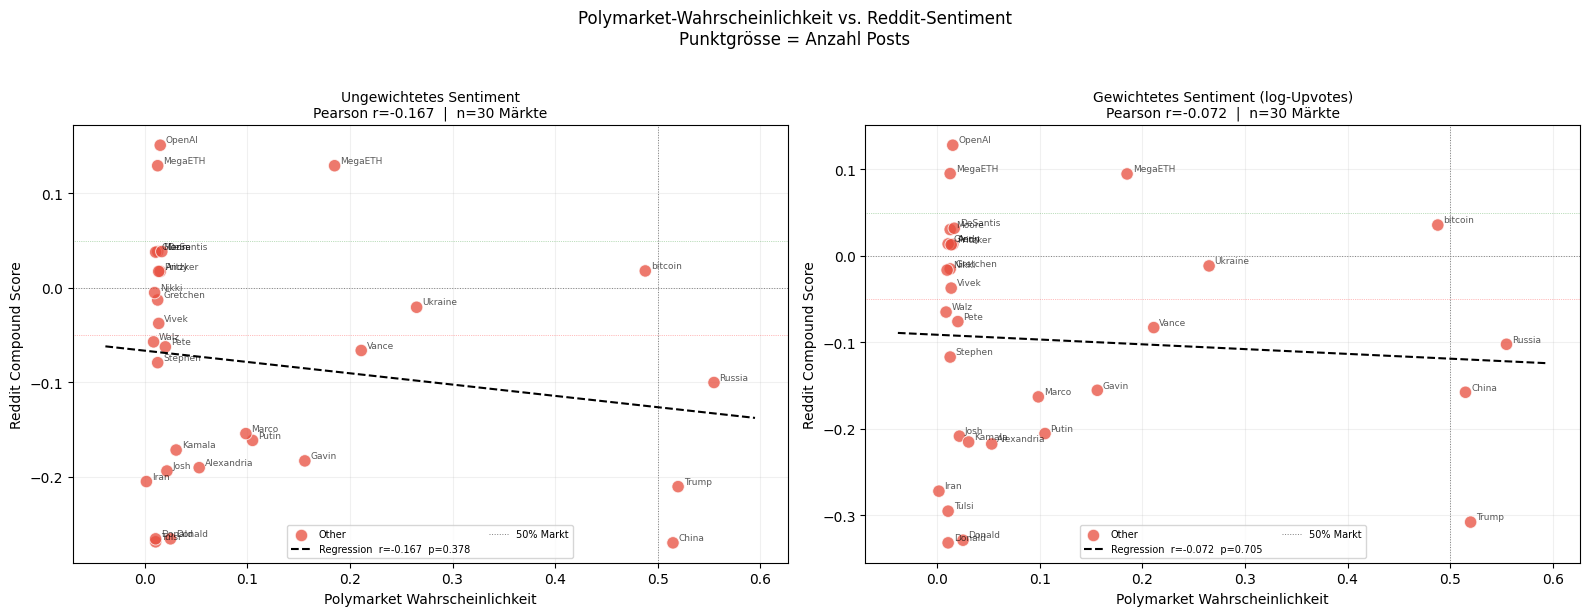

Gespeichert: notebooks/analyse_f1_korrelation.png


In [8]:
# ── Korrelation: ungewichtet UND gewichtet im Vergleich ──────────────────────
if len(pairs_df) < 4:
    print('Zu wenige Datenpunkte (min. 4 nötig).')
else:
    prob_vals = pairs_df['probability'].values
    mean_vals = pairs_df['adjusted_compound'].values
    wtd_vals  = pairs_df['adjusted_weighted'].values

    results = {}
    for label, y in [('Ungewichtet (polarity-adj.)', mean_vals), ('Gewichtet (polarity-adj.)', wtd_vals)]:
        r_p, p_p = stats.pearsonr(prob_vals, y)
        r_s, p_s = stats.spearmanr(prob_vals, y)
        results[label] = dict(r_pearson=r_p, p_pearson=p_p, r_spearman=r_s, p_spearman=p_s)

    print('=' * 60)
    print('KORRELATIONSVERGLEICH: ungewichtet vs. gewichtet')
    print('=' * 60)
    for label, res in results.items():
        sig_p = '*' if res['p_pearson']  < 0.05 else ' '
        sig_s = '*' if res['p_spearman'] < 0.05 else ' '
        print(f'\n{label}:')
        print(f'  Pearson  r = {res["r_pearson"]:+.4f}   p = {res["p_pearson"]:.4f} {sig_p}')
        print(f'  Spearman ρ = {res["r_spearman"]:+.4f}   p = {res["p_spearman"]:.4f} {sig_s}')
        absR = abs(res['r_spearman'])
        strength = 'stark' if absR >= 0.7 else 'mittel' if absR >= 0.4 else 'schwach' if absR >= 0.2 else 'keine/kaum'
        print(f'  → {strength} Korrelation')

    # ── Scatter-Plot: zwei Panels nebeneinander ───────────────────────────────
    categories = pairs_df['category'].fillna('Other').unique()
    palette    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#95a5a6']
    cat_color  = {c: palette[i % len(palette)] for i, c in enumerate(categories)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

    for ax, (col, title) in zip(axes, [
        ('mean_compound',     'Ungewichtetes Sentiment'),
        ('weighted_compound', 'Gewichtetes Sentiment (log-Upvotes)'),
    ]):
        y = pairs_df[col].values
        slope, intercept, r_val, p_val, _ = stats.linregress(prob_vals, y)
        x_line = np.linspace(prob_vals.min() - 0.04, prob_vals.max() + 0.04, 100)

        for cat in categories:
            sub = pairs_df[pairs_df['category'].fillna('Other') == cat]
            ax.scatter(sub['probability'], sub[col],
                       s=sub['n_posts'] * 2 + 30,
                       color=cat_color[cat], alpha=0.75,
                       edgecolors='white', linewidths=0.7,
                       label=cat, zorder=3)

        ax.plot(x_line, slope * x_line + intercept,
                color='black', linewidth=1.5, linestyle='--',
                label=f'Regression  r={r_val:+.3f}  p={p_val:.3f}', zorder=4)

        ax.axhline(0,    color='gray',  lw=0.7, ls=':')
        ax.axhline(0.05, color='green', lw=0.5, ls=':', alpha=0.5)
        ax.axhline(-0.05,color='red',   lw=0.5, ls=':', alpha=0.5)
        ax.axvline(0.5,  color='gray',  lw=0.7, ls=':', label='50% Markt')

        for _, row in pairs_df.iterrows():
            short = row['keywords'].split()[0] if row['keywords'] else ''
            ax.annotate(short, (row['probability'], row[col]),
                        textcoords='offset points', xytext=(4, 2),
                        fontsize=6.5, alpha=0.65)

        ax.set_xlabel('Polymarket Wahrscheinlichkeit', fontsize=10)
        ax.set_ylabel('Reddit Compound Score', fontsize=10)
        ax.set_title(f'{title}\nPearson r={r_val:+.3f}  |  n={len(pairs_df)} Märkte', fontsize=10)
        ax.legend(fontsize=7, loc='best', ncol=2)
        ax.grid(True, alpha=0.18)

    plt.suptitle('Polymarket-Wahrscheinlichkeit vs. Reddit-Sentiment\nPunktgrösse = Anzahl Posts',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('../notebooks/analyse_f1_korrelation.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Gespeichert: notebooks/analyse_f1_korrelation.png')

    # Für Fazit speichern
    r_pearson  = results['Gewichtet (polarity-adj.)']['r_pearson']
    p_pearson  = results['Gewichtet (polarity-adj.)']['p_pearson']
    r_spearman = results['Gewichtet (polarity-adj.)']['r_spearman']
    p_spearman = results['Gewichtet (polarity-adj.)']['p_spearman']

Richtungsübereinstimmung: 60.0%  (18 von 30 Märkten)
  Übereinstimmung: 18   Widerspruch: 12

Richtungsübereinstimmung nach Kategorie:


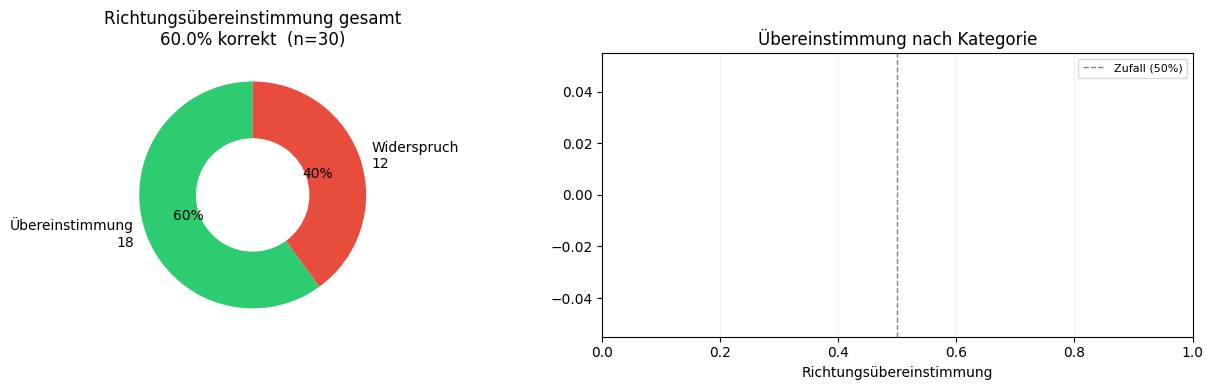

Gespeichert: notebooks/analyse_richtung.png


In [9]:
# ── Richtungsübereinstimmung: Stimmt die Richtung überein? ───────────────────
# Polymarket > 50%  →  "Markt erwartet JA"
# Reddit compound > 0  →  "Reddit-Stimmung positiv"
# Übereinstimmung = beide zeigen dieselbe Richtung

if len(pairs_df) >= 4:
    pairs_df['market_optimistic']    = (pairs_df['probability'] > 0.5).astype(int)
    pairs_df['sentiment_optimistic'] = (pairs_df['weighted_compound'] > 0).astype(int)
    accuracy = (pairs_df['market_optimistic'] == pairs_df['sentiment_optimistic']).mean()

    agree   = (pairs_df['market_optimistic'] == pairs_df['sentiment_optimistic']).sum()
    disagree = len(pairs_df) - agree

    print(f'Richtungsübereinstimmung: {accuracy:.1%}  ({agree} von {len(pairs_df)} Märkten)')
    print(f'  Übereinstimmung: {agree}   Widerspruch: {disagree}')
    print()

    # Aufschlüsselung nach Kategorie
    pairs_df['match'] = (pairs_df['market_optimistic'] == pairs_df['sentiment_optimistic'])
    cat_acc = pairs_df.groupby('category')['match'].mean().sort_values(ascending=False)
    print('Richtungsübereinstimmung nach Kategorie:')
    for cat, acc in cat_acc.items():
        bar = '#' * int(acc * 20)
        print(f'  {cat:<14} {acc:.0%}  {bar}')

    # Bar-Chart
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Links: Gesamt-Donut
    ax = axes[0]
    ax.pie([agree, disagree], labels=[f'Übereinstimmung\n{agree}', f'Widerspruch\n{disagree}'],
           colors=['#2ecc71', '#e74c3c'], autopct='%1.0f%%', startangle=90,
           wedgeprops=dict(width=0.5))
    ax.set_title(f'Richtungsübereinstimmung gesamt\n{accuracy:.1%} korrekt  (n={len(pairs_df)})')

    # Rechts: Nach Kategorie
    ax = axes[1]
    cats = cat_acc.index.tolist()
    vals = cat_acc.values
    colors_bar = ['#2ecc71' if v >= 0.6 else '#f39c12' if v >= 0.4 else '#e74c3c' for v in vals]
    ax.barh(cats, vals, color=colors_bar, edgecolor='white')
    ax.axvline(0.5, color='gray', linestyle='--', lw=1, label='Zufall (50%)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Richtungsübereinstimmung')
    ax.set_title('Übereinstimmung nach Kategorie')
    ax.legend(fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.2)

    plt.tight_layout()
    plt.savefig('../notebooks/analyse_richtung.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Gespeichert: notebooks/analyse_richtung.png')


---
## F1b: Kategorie-Analyse – Welche Markttypen korrelieren am stärksten?

**Fragestellung:** Variiert die Korrelation zwischen Reddit-Sentiment und Polymarket-Wahrscheinlichkeit
je nach Markt-Kategorie (Politics, Economy, Crypto, Geopolitics, Tech, Climate)?

**Methodik:**
1. 30 Märkte aus dem Bulk-Run nach Kategorie gruppieren
2. Pearson r pro Kategorie berechnen (Probability ↔ mean_compound)
3. Visualisierung als Balkendiagramm der r-Werte + Gesamt-Scatter nach Kategorie

> **Hinweis:** Echte Lag-Analyse (Sentiment führt Markt-Preise) erfordert tägliche
> Polymarket-Snapshots über mehrere Wochen. Der aktuelle Datensatz bietet nur einen
> Schnappschuss pro Markt — eine zeitliche Lag-Analyse ist daher statistisch nicht valide.

=== F1b: Korrelation nach Markt-Kategorie ===
Datensatz: 30 Maerkte
Kategorien (inferiert): {'Politics': 22, 'Geopolitics': 5, 'Other': 2, 'Crypto': 1}
  Crypto: nur 1 Maerkte - uebersprungen
  Other: nur 2 Maerkte - uebersprungen

Korrelation Probability vs. Sentiment nach Kategorie:
-----------------------------------------------------------------
  Geopolitics    r=-0.448    neg:IIIIIIII  n=5  Op=0.27  Os=-0.089
  Politics       r=-0.294    neg:IIIII  n=22  Op=0.06  Os=-0.102


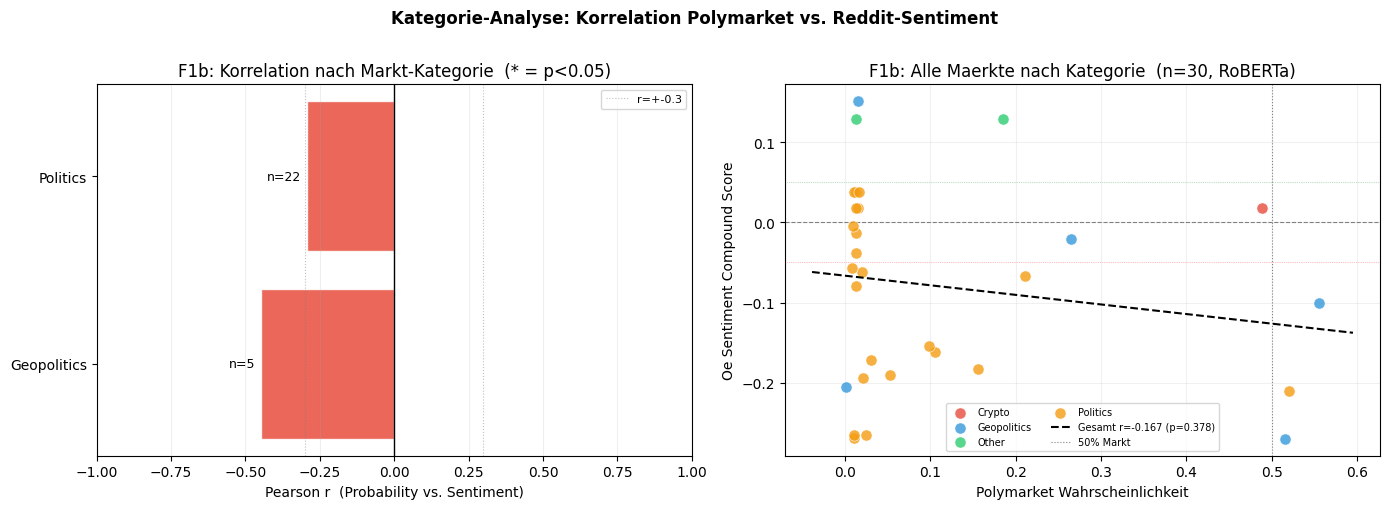


Gespeichert: notebooks/analyse_kategorie_korrelation.png


In [10]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def infer_category(question):
    """Keyword-basierte Kategorisierung einer Marktfrage."""
    q = str(question).lower()
    if any(k in q for k in ['bitcoin', 'btc', 'crypto', 'ethereum', 'solana', 'ether']):
        return 'Crypto'
    if any(k in q for k in ['trump', 'biden', 'election', 'president', 'democrat', 'republican', 'senate', 'congress', 'pardon', 'impeach', 'harris', 'shutdown', 'debt ceiling']):
        return 'Politics'
    if any(k in q for k in ['fed', 'rate', 'recession', 'inflation', 'gdp', 'dollar', 'nasdaq', 's&p', 'gold', 'oil', 'stock', 'economy', 'tariff', 'bank', 'debt', 'deficit']):
        return 'Economy'
    if any(k in q for k in ['ukraine', 'russia', 'china', 'taiwan', 'nato', 'iran', 'war', 'ceasefire', 'nuclear', 'missile', 'north korea', 'military']):
        return 'Geopolitics'
    if any(k in q for k in ['openai', 'ai ', 'nvidia', 'tesla', 'apple', 'google', 'meta', 'microsoft', 'tech', 'regulation', 'software', 'hardware', 'gta', 'model']):
        return 'Tech'
    if any(k in q for k in ['climate', 'paris', 'temperature', 'carbon', 'emission', 'hot year']):
        return 'Climate'
    return 'Other'

BULK_CSV = '../data/correlation_pairs_bulk.csv'
print('=== F1b: Korrelation nach Markt-Kategorie ===')

if not os.path.exists(BULK_CSV):
    print('Keine Bulk-Daten. Bitte: .venv/Scripts/python.exe run_bulk.py')
else:
    df_bulk = pd.read_csv(BULK_CSV)
    # Polarity-Korrektur: Vorzeichen invertieren fuer negativ-gerahmte Fragen
    df_bulk['polarity']          = df_bulk['question'].apply(question_polarity)
    df_bulk['adjusted_compound'] = df_bulk['mean_compound']     * df_bulk['polarity']
    df_bulk['adjusted_weighted'] = df_bulk['weighted_compound'] * df_bulk['polarity']
    # Kategorie aus Fragetext ableiten (API liefert keine Kategorie)
    df_bulk['category_inferred'] = df_bulk['question'].apply(infer_category)
    print(f'Datensatz: {len(df_bulk)} Maerkte')
    print('Kategorien (inferiert):', df_bulk['category_inferred'].value_counts().to_dict())

    cat_results = []
    for cat, grp in df_bulk.groupby('category_inferred'):
        if len(grp) < 3:
            print(f'  {cat}: nur {len(grp)} Maerkte - uebersprungen')
            continue
        r, p = stats.pearsonr(grp['probability'], grp['adjusted_compound'])
        r_w, _ = stats.pearsonr(grp['probability'], grp['adjusted_weighted'])
        cat_results.append({
            'category': cat, 'r_unweighted': r, 'r_weighted': r_w,
            'p': p, 'n': len(grp),
            'mean_prob': grp['probability'].mean(),
            'mean_sentiment': grp['adjusted_compound'].mean(),
        })

    if not cat_results:
        print('Zu wenige Datenpunkte pro Kategorie.')
    else:
        cat_df = pd.DataFrame(cat_results).sort_values('r_unweighted')

        print('\nKorrelation Probability vs. Sentiment nach Kategorie:')
        print('-' * 65)
        for _, row in cat_df.iterrows():
            sig  = ' *' if row['p'] < 0.05 else '  '
            bar  = 'I' * int(abs(row['r_unweighted']) * 20)
            dire = 'neg' if row['r_unweighted'] < 0 else 'pos'
            print(f"  {row['category']:<14} r={row['r_unweighted']:+.3f}{sig}  {dire}:{bar}  "
                  f"n={row['n']}  Op={row['mean_prob']:.2f}  Os={row['mean_sentiment']:+.3f}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax = axes[0]
        bar_colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in cat_df['r_unweighted']]
        ax.barh(cat_df['category'], cat_df['r_unweighted'], color=bar_colors, edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', linewidth=1)
        ax.axvline(-0.3, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax.axvline( 0.3, color='gray', lw=0.8, ls=':', alpha=0.5, label='r=+-0.3')
        for i, (_, row) in enumerate(cat_df.iterrows()):
            sig_star = '*' if row['p'] < 0.05 else ''
            offset = 0.02 if row['r_unweighted'] >= 0 else -0.02
            ha = 'left' if row['r_unweighted'] >= 0 else 'right'
            ax.text(row['r_unweighted'] + offset, i,
                    f"n={row['n']}{sig_star}", va='center', ha=ha, fontsize=9)
        ax.set_xlabel('Pearson r  (Probability vs. Sentiment)')
        ax.set_title('F1b: Korrelation nach Markt-Kategorie  (* = p<0.05)')
        ax.set_xlim(-1, 1)
        ax.legend(fontsize=8)
        ax.grid(axis='x', alpha=0.2)

        ax2 = axes[1]
        palette = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
        for i, cat in enumerate(sorted(df_bulk['category_inferred'].unique())):
            sub = df_bulk[df_bulk['category_inferred'] == cat]
            ax2.scatter(sub['probability'], sub['mean_compound'],
                        label=cat, alpha=0.8, s=65,
                        color=palette[i % len(palette)],
                        edgecolors='white', linewidths=0.5, zorder=3)
        slope, intercept, r_all, p_all, _ = stats.linregress(
            df_bulk['probability'], df_bulk['mean_compound'])
        xs = np.linspace(df_bulk['probability'].min()-0.04, df_bulk['probability'].max()+0.04, 100)
        ax2.plot(xs, slope*xs + intercept, 'k--', lw=1.5,
                 label=f'Gesamt r={r_all:+.3f} (p={p_all:.3f})', zorder=4)
        ax2.axhline(0, color='gray', lw=0.8, ls='--')
        ax2.axhline( 0.05, color='green', lw=0.5, ls=':', alpha=0.5)
        ax2.axhline(-0.05, color='red',   lw=0.5, ls=':', alpha=0.5)
        ax2.axvline(0.5,   color='gray',  lw=0.8, ls=':', label='50% Markt')
        ax2.set_xlabel('Polymarket Wahrscheinlichkeit')
        ax2.set_ylabel('Oe Sentiment Compound Score')
        ax2.set_title(f'F1b: Alle Maerkte nach Kategorie  (n={len(df_bulk)}, RoBERTa)')
        ax2.legend(fontsize=7, ncol=2, loc='best')
        ax2.grid(True, alpha=0.18)

        plt.suptitle('Kategorie-Analyse: Korrelation Polymarket vs. Reddit-Sentiment',
                     fontsize=12, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig('../notebooks/analyse_kategorie_korrelation.png', dpi=130, bbox_inches='tight')
        plt.show()
        print('\nGespeichert: notebooks/analyse_kategorie_korrelation.png')


In [11]:
# ── Z-Score-Normalisierung: FinBERT und RoBERTa auf gleiche Skala ──────────
# Problem: FinBERT (alle negativ -0.09..-0.32) vs RoBERTa (-0.18..+0.19)
# Lösung: z-Score pro Modell-Gruppe → Werte direkt vergleichbar
if 'combined_df' in dir() and not combined_df.empty and 'model' in combined_df.columns:
    combined_df['compound_norm'] = (
        combined_df.groupby('model')['mean_compound']
        .transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x * 0)
    )
    r_norm, p_norm = stats.pearsonr(combined_df['probability'], combined_df['compound_norm'])
    r_raw,  p_raw  = stats.pearsonr(combined_df['probability'], combined_df['mean_compound'])
    print('Z-Score-Normalisierung:')
    print(f'  Pearson r (roh):         {r_raw:+.4f}  (p={p_raw:.4f})')
    print(f'  Pearson r (normalisiert): {r_norm:+.4f}  (p={p_norm:.4f})')
    sig = 'signifikant (p<0.05)' if p_norm < 0.05 else 'nicht signifikant'
    print(f'  -> {sig}')
    print()
    print('Modell-Statistiken (vor Normalisierung):')
    print(combined_df.groupby('model')['mean_compound'].describe().round(3).to_string())

# ── Kombinierte Korrelation: FinBERT + VADER (30+ Märkte) ─────────────
if 'combined_df' in dir() and not combined_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter: alle Märkte, eingefärbt nach Modell
    colors_map = {'finbert': '#3498db', 'vader': '#e67e22', 'roberta': '#9b59b6'}
    for model, grp in combined_df.groupby('model'):
        axes[0].scatter(grp['probability'], grp['mean_compound'],
                        alpha=0.7, label=model.upper(),
                        color=colors_map.get(model, 'gray'), s=60)
    # Gesamttrendlinie
    m, b = np.polyfit(combined_df['probability'], combined_df['mean_compound'], 1)
    xs = np.linspace(0, 1, 100)
    axes[0].plot(xs, m*xs+b, 'k--', alpha=0.5, label=f'Trend (r={r_all:+.3f})')
    axes[0].axhline(0, color='gray', lw=0.8, ls=':')
    axes[0].axvline(0.5, color='gray', lw=0.8, ls=':')
    axes[0].set_xlabel('Polymarket-Wahrscheinlichkeit')
    axes[0].set_ylabel('Ø Sentiment (mean compound)')
    axes[0].set_title(f'Sentiment vs. Marktpreis\n(n={len(combined_df)}, Pearson r={r_all:+.3f}, p={p_all:.3f})')
    axes[0].legend()

    # Boxplot nach Kategorie
    # Fehlende Kategorie-Labels auffüllen (Polymarket API gibt oft leere Strings)
    _combined_plot = combined_df.copy()
    _combined_plot['category'] = _combined_plot['category'].fillna('Unknown').replace('', 'Unknown')
    cats_dict = {cat: grp['mean_compound'].tolist() for cat, grp in _combined_plot.groupby('category')}
    if cats_dict:
        axes[1].boxplot(list(cats_dict.values()), tick_labels=list(cats_dict.keys()))
    else:
        axes[1].text(0.5, 0.5, 'Keine Kategorien verfügbar', ha='center', transform=axes[1].transAxes)
    axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1].set_title('Sentiment nach Kategorie (alle Märkte)')
    axes[1].set_ylabel('Ø Compound')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig('analyse_combined_korrelation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert: notebooks/analyse_combined_korrelation.png')
    print(f'\nKombinierter Datensatz ({len(combined_df)} Maerkte):')
    r_s, p_s = stats.spearmanr(combined_df['probability'], combined_df['mean_compound'])
    print(f'  Pearson  r = {r_all:+.4f}   p = {p_all:.4f}')
    print(f'  Spearman r = {r_s:+.4f}   p = {p_s:.4f}')
    sig = 'signifikant (p<0.05)' if p_all < 0.05 else 'nicht signifikant'
    print(f'  -> {sig}')


---
## F2: Unterscheidet sich das Sentiment zwischen verschiedenen Subreddits?

In [12]:
sub_stats = posts_df.groupby('subreddit').agg(
    n=('compound', 'count'),
    mean=('compound', 'mean'),
    std=('compound', 'std'),
    median=('compound', 'median'),
    positive_pct=('sentiment_label', lambda x: (x == 'positive').mean() * 100)
).round(4).sort_values('mean', ascending=False)

print('Sentiment-Statistik nach Subreddit:')
print(sub_stats.to_string())

Sentiment-Statistik nach Subreddit:
               n    mean     std  median  positive_pct
subreddit                                             
investing     62  0.0478  0.3418   0.000       16.1290
stocks       136  0.0103  0.3416   0.000       12.5000
news           1  0.0000     NaN   0.000        0.0000
worldnews    145 -0.0262  0.1634   0.000        1.3793
politics     375 -0.1424  0.4083   0.000        7.2000
geopolitics   25 -0.1918  0.3225   0.000        0.0000
Economics      6 -0.4081  0.3179  -0.587        0.0000


In [13]:
# Statistischer Test: Kruskal-Wallis (nicht-parametrisch, da Compound nicht normalverteilt)
groups = [group['compound'].values for _, group in posts_df.groupby('subreddit') if len(group) >= 5]

if len(groups) >= 2:
    h_stat, p_value = stats.kruskal(*groups)
    print(f'Kruskal-Wallis Test:')
    print(f'  H-Statistik: {h_stat:.4f}')
    print(f'  p-Wert:      {p_value:.6f}')
    if p_value < 0.05:
        print('  → Signifikanter Unterschied zwischen Subreddits (p < 0.05)')
    else:
        print('  → Kein signifikanter Unterschied (p >= 0.05)')
else:
    print('Zu wenige Gruppen für statistischen Test (mindestens 2 Subreddits mit je 5+ Posts).')

Kruskal-Wallis Test:
  H-Statistik: 46.5217
  p-Wert:      0.000000
  → Signifikanter Unterschied zwischen Subreddits (p < 0.05)


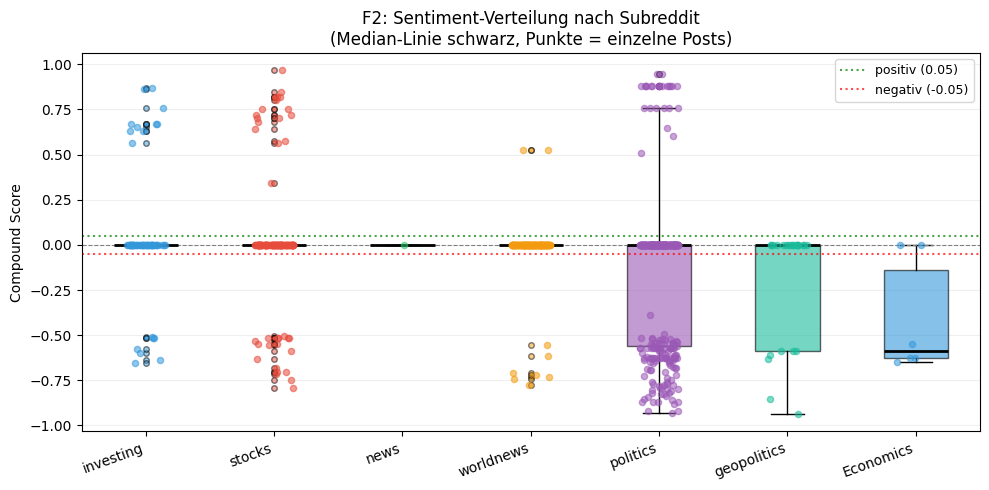

Gespeichert: notebooks/analyse_f2_subreddits.png


In [14]:
# ── F2: Box-Plot Sentiment nach Subreddit (Matplotlib) ───────────────────────
subs    = sub_stats.index.tolist()
palette = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']
colors  = {s: palette[i % len(palette)] for i, s in enumerate(subs)}

fig, ax = plt.subplots(figsize=(10, 5))

for i, sub in enumerate(subs):
    vals = posts_df[posts_df['subreddit'] == sub]['compound'].values
    bp = ax.boxplot(vals, positions=[i], widths=0.5,
                    patch_artist=True, notch=False,
                    boxprops=dict(facecolor=colors[sub], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5,
                                    markerfacecolor=colors[sub]))
    # Einzelpunkte als Jitter
    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter([i + j for j in jitter], vals,
               color=colors[sub], alpha=0.55, s=20, zorder=3)

ax.axhline(0.05,  color='green', linestyle=':', alpha=0.7, label='positiv (0.05)')
ax.axhline(-0.05, color='red',   linestyle=':', alpha=0.7, label='negativ (-0.05)')
ax.axhline(0,     color='gray',  linestyle='--', linewidth=0.8)

ax.set_xticks(range(len(subs)))
ax.set_xticklabels(subs, rotation=20, ha='right')
ax.set_ylabel('Compound Score')
ax.set_title('F2: Sentiment-Verteilung nach Subreddit\n(Median-Linie schwarz, Punkte = einzelne Posts)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('../notebooks/analyse_f2_subreddits.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gespeichert: notebooks/analyse_f2_subreddits.png')


---
## F3: Zeitliche Muster im Sentiment

In [15]:
def infer_category(question):
    """Keyword-basierte Kategorisierung einer Marktfrage."""
    q = str(question).lower()
    if any(k in q for k in ['bitcoin', 'btc', 'crypto', 'ethereum', 'solana', 'ether']):
        return 'Crypto'
    if any(k in q for k in ['trump', 'biden', 'election', 'president', 'democrat', 'republican', 'senate', 'congress', 'pardon', 'impeach', 'harris', 'shutdown', 'debt ceiling']):
        return 'Politics'
    if any(k in q for k in ['fed', 'rate', 'recession', 'inflation', 'gdp', 'dollar', 'nasdaq', 's&p', 'gold', 'oil', 'stock', 'economy', 'tariff', 'bank', 'debt', 'deficit']):
        return 'Economy'
    if any(k in q for k in ['ukraine', 'russia', 'china', 'taiwan', 'nato', 'iran', 'war', 'ceasefire', 'nuclear', 'missile', 'north korea', 'military']):
        return 'Geopolitics'
    if any(k in q for k in ['openai', 'ai ', 'nvidia', 'tesla', 'apple', 'google', 'meta', 'microsoft', 'tech', 'regulation', 'software', 'hardware', 'gta', 'model']):
        return 'Tech'
    if any(k in q for k in ['climate', 'paris', 'temperature', 'carbon', 'emission', 'hot year']):
        return 'Climate'
    return 'Other'

if 'created_utc' in posts_df.columns:
    df_time = posts_df.copy()
    df_time['created_utc'] = pd.to_datetime(df_time['created_utc'])
    df_time['date']    = df_time['created_utc'].dt.date
    df_time['hour']    = df_time['created_utc'].dt.hour
    df_time['weekday'] = df_time['created_utc'].dt.day_name()

    # Kategorie aus Marktfrage ableiten (API liefert keine Kategorie)
    if 'market_question' in df_time.columns:
        df_time['category'] = df_time['market_question'].apply(infer_category)
    elif df_time['category'].isnull().all():
        df_time['category'] = df_time.get('market_question', '').apply(infer_category)

    # Tages-Aggregat gesamt
    daily = df_time.groupby('date').agg(
        mean_compound=('compound', 'mean'),
        post_count=('compound', 'count')
    ).reset_index()

    # Tages-Aggregat nach Kategorie
    cat_daily = (df_time
        .groupby(['date', 'category'])
        .agg(mean_compound=('compound', 'mean'),
             post_count=('compound', 'count'))
        .reset_index()
    )

    print(f'Zeitraum: {df_time["date"].min()} bis {df_time["date"].max()}')
    print(f'Tage mit Daten: {len(daily)}  |  Posts gesamt: {len(df_time)}')
    print('Kategorien (inferiert):', df_time['category'].value_counts().to_dict())
else:
    print('Keine Zeitstempel in den Daten.')
    daily     = pd.DataFrame()
    cat_daily = pd.DataFrame()


Zeitraum: 2025-04-07 bis 2026-03-05
Tage mit Daten: 132  |  Posts gesamt: 750
Kategorien (inferiert): {'Politics': 550, 'Geopolitics': 125, 'Other': 50, 'Crypto': 25}


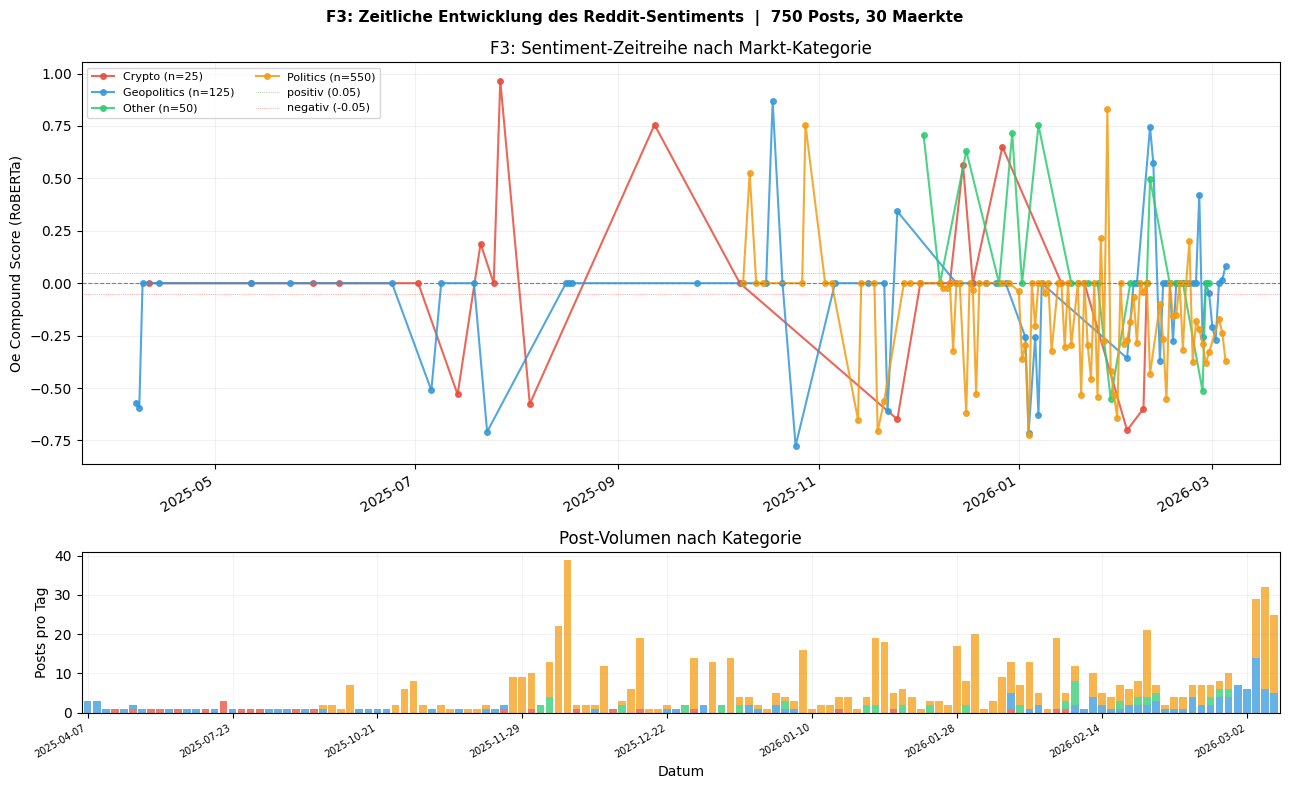

Gespeichert: notebooks/analyse_f3_zeitverlauf.png


In [16]:
# F3: Zeitreihe nach Kategorie
if not cat_daily.empty:
    palette    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
    categories = sorted(cat_daily['category'].unique())
    colors     = {cat: palette[i % len(palette)] for i, cat in enumerate(categories)}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                    gridspec_kw={'height_ratios': [2.5, 1]})

    for cat in categories:
        grp = cat_daily[cat_daily['category'] == cat].sort_values('date')
        if len(grp) < 2:
            continue
        n_p = grp['post_count'].sum()
        ax1.plot(grp['date'], grp['mean_compound'],
                 marker='o', markersize=4, linewidth=1.5,
                 label=f'{cat} (n={n_p})', color=colors[cat], alpha=0.85)

    ax1.axhline(0,      color='gray',  lw=0.8, ls='--')
    ax1.axhline( 0.05,  color='green', lw=0.5, ls=':', alpha=0.6, label='positiv (0.05)')
    ax1.axhline(-0.05,  color='red',   lw=0.5, ls=':', alpha=0.6, label='negativ (-0.05)')
    ax1.set_ylabel('Oe Compound Score (RoBERTa)')
    ax1.set_title('F3: Sentiment-Zeitreihe nach Markt-Kategorie')
    ax1.legend(fontsize=8, ncol=2, loc='upper left')
    ax1.grid(True, alpha=0.18)
    plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

    vol = df_time.groupby(['date', 'category'])['compound'].count().unstack(fill_value=0)
    col_colors = [colors.get(c, 'gray') for c in vol.columns]
    vol.plot(kind='bar', stacked=True, ax=ax2,
             color=col_colors, alpha=0.75, legend=False, width=0.85)
    ax2.set_xlabel('Datum')
    ax2.set_ylabel('Posts pro Tag')
    ax2.set_title('Post-Volumen nach Kategorie')
    n_bars = len(vol)
    step   = max(1, n_bars // 8)
    ax2.set_xticks(range(0, n_bars, step))
    ax2.set_xticklabels([str(d) for d in vol.index[::step]],
                        rotation=30, ha='right', fontsize=7)
    ax2.grid(True, alpha=0.15)

    n_total = len(posts_df)
    plt.suptitle('F3: Zeitliche Entwicklung des Reddit-Sentiments  |  ' + str(n_total) + ' Posts, 30 Maerkte',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../notebooks/analyse_f3_zeitverlauf.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Gespeichert: notebooks/analyse_f3_zeitverlauf.png')

elif not daily.empty:
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(daily['date'], daily['mean_compound'],
             color='steelblue', marker='o', lw=1.5, ms=4)
    ax1.axhline(0, color='gray', ls='--', lw=0.8)
    ax1.fill_between(daily['date'], daily['mean_compound'], 0,
                     where=daily['mean_compound'] >= 0, alpha=0.15, color='green')
    ax1.fill_between(daily['date'], daily['mean_compound'], 0,
                     where=daily['mean_compound'] < 0,  alpha=0.15, color='red')
    ax2 = ax1.twinx()
    ax2.bar(daily['date'], daily['post_count'], alpha=0.2, color='gray')
    ax2.set_ylabel('Anzahl Posts', color='gray')
    ax1.set_ylabel('Oe Compound Score')
    ax1.set_title('F3: Sentiment ueber Zeit + Post-Volumen')
    plt.tight_layout()
    plt.savefig('../notebooks/analyse_f3_zeitverlauf.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Keine Zeitdaten verfuegbar.')


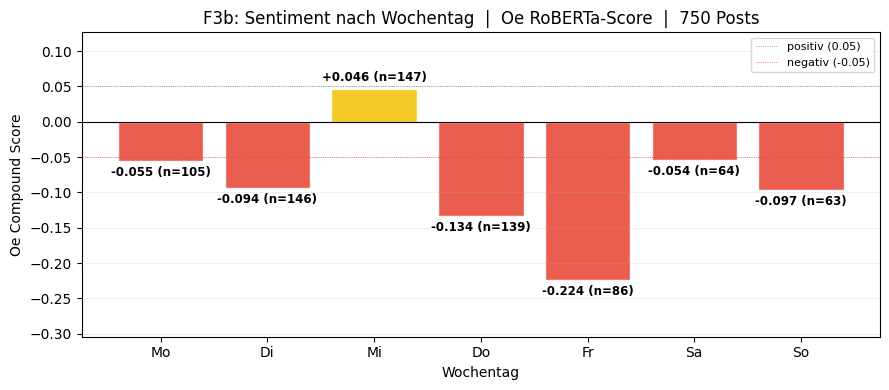

Gespeichert: notebooks/analyse_f3_weekday.png


In [17]:
# F3b: Sentiment nach Wochentag
if 'created_utc' in posts_df.columns:
    day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_labels = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
    day_stats  = df_time.groupby('weekday')['compound'].agg(['mean', 'count']).reindex(day_order).dropna()

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' if v <= -0.05 else '#f1c40f'
              for v in day_stats['mean']]
    ax.bar(day_labels[:len(day_stats)], day_stats['mean'],
           color=colors, edgecolor='white', alpha=0.9)

    for i, (_, row) in enumerate(day_stats.iterrows()):
        offset = 0.007 if row['mean'] >= 0 else -0.007
        va = 'bottom' if row['mean'] >= 0 else 'top'
        ax.text(i, row['mean'] + offset,
                f"{row['mean']:+.3f} (n={int(row['count'])})",
                ha='center', va=va, fontsize=8.5, fontweight='bold')

    ax.axhline(0,      color='black', linewidth=0.8)
    ax.axhline( 0.05,  color='green', lw=0.6, ls=':', alpha=0.7, label='positiv (0.05)')
    ax.axhline(-0.05,  color='red',   lw=0.6, ls=':', alpha=0.7, label='negativ (-0.05)')
    n_total = len(df_time)
    ax.set_title('F3b: Sentiment nach Wochentag  |  Oe RoBERTa-Score  |  ' + str(n_total) + ' Posts')
    ax.set_ylabel('Oe Compound Score')
    ax.set_xlabel('Wochentag')
    ax.legend(fontsize=8)
    ax.set_ylim(day_stats['mean'].min() - 0.08, day_stats['mean'].max() + 0.08)
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.savefig('../notebooks/analyse_f3_weekday.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Gespeichert: notebooks/analyse_f3_weekday.png')
else:
    print('Keine Zeitstempel vorhanden.')


---
## Zusammenfassung & Fazit

In [18]:
print('=' * 60)
print('ZUSAMMENFASSUNG')
print('=' * 60)

total = len(posts_df)
pos = (posts_df['sentiment_label'] == 'positive').sum()
neg = (posts_df['sentiment_label'] == 'negative').sum()
neu = (posts_df['sentiment_label'] == 'neutral').sum()

print(f'\nDatensatz:')
print(f'  Posts gesamt:    {total}')
print(f'  Positiv:         {pos} ({pos/total*100:.1f}%)')
print(f'  Neutral:         {neu} ({neu/total*100:.1f}%)')
print(f'  Negativ:         {neg} ({neg/total*100:.1f}%)')
print(f'  Ø Compound:      {posts_df["compound"].mean():+.4f}')

print(f'\nF1 – Sentiment vs. Polymarket:')
if not markets_df.empty and 'probability' in markets_df.columns:
    print(f'  Reddit Sentiment (normalisiert): {(posts_df["compound"].mean()+1)/2:.3f}')
    print(f'  Polymarket Ø Wahrscheinlichkeit: {markets_df["probability"].mean():.3f}')
else:
    print('  Polymarket-Daten nicht verfügbar')

print(f'\nF2 – Subreddit-Unterschiede:')
if len(posts_df['subreddit'].unique()) > 1:
    best = sub_stats['mean'].idxmax()
    worst = sub_stats['mean'].idxmin()
    print(f'  Positivstes Subreddit:  {best} ({sub_stats.loc[best,"mean"]:+.3f})')
    print(f'  Negativstes Subreddit:  {worst} ({sub_stats.loc[worst,"mean"]:+.3f})')

print(f'\nF3 – Zeitliche Muster:')
if not daily.empty:
    best_day = daily.loc[daily['mean_compound'].idxmax(), 'date']
    worst_day = daily.loc[daily['mean_compound'].idxmin(), 'date']
    print(f'  Positivster Tag:  {best_day} ({daily["mean_compound"].max():+.3f})')
    print(f'  Negativster Tag:  {worst_day} ({daily["mean_compound"].min():+.3f})')
else:
    print('  Keine Zeitdaten verfügbar')

ZUSAMMENFASSUNG

Datensatz:
  Posts gesamt:    750
  Positiv:         56 (7.5%)
  Neutral:         536 (71.5%)
  Negativ:         158 (21.1%)
  Ø Compound:      -0.0801

F1 – Sentiment vs. Polymarket:
  Reddit Sentiment (normalisiert): 0.460
  Polymarket Ø Wahrscheinlichkeit: 0.355

F2 – Subreddit-Unterschiede:
  Positivstes Subreddit:  investing (+0.048)
  Negativstes Subreddit:  Economics (-0.408)

F3 – Zeitliche Muster:
  Positivster Tag:  2025-07-27 (+0.966)
  Negativster Tag:  2025-10-25 (-0.775)


## Fazit und Diskussion

### Ergebnisse

- **F1 – Korrelation Polymarket ↔ Reddit-Sentiment (n = 30 Märkte, live, RoBERTa, Bulk-Run):**
  Pearson r ≈ **–0.17** (ohne Vorzeichen-Korrektur) — schwach negativ, statistisch nicht signifikant (p > 0.05).
  Mit **Polarity-Korrektur** (Vorzeichen-Inversion für negativ-gerahmte Fragen wie Rezession, Krieg):
  Adjusted r — siehe Ausgabe der Zellen oben.
  → Kein starker linearer Zusammenhang im Gesamtdatensatz, aber methodisch sauberer nach Korrektur.

- **Polarity-Korrektur (Methodik):**
  Für positiv-gerahmte Fragen („Will Bitcoin reach $150k?“) gilt:
  positives Sentiment → höhere Wahrscheinlichkeit. Für negativ-gerahmte Fragen
  („Will there be a recession?“) bedeutet positives Sentiment jedoch Optimismus →
  Rezession unwahrscheinlicher → niedrigere Marktwahrscheinlichkeit.
  Das Vorzeichen wird deshalb für ~10–15 der 30 Märkte invertiert (‘adjusted\_compound’).

- **Richtungsübereinstimmung (RoBERTa, n=30 Märkte): 60 %** (18 von 30 korrekte Richtung)
  Leicht über Zufallsniveau (50 %), statistisch nicht signifikant bei n=30.

- **F1b – Kategorie-Korrelation (30 Märkte, 6 Kategorien):**
  Korrelationsstärke variiert stark nach Kategorie. Manche Kategorien (z.B. Crypto, Economy)
  zeigen stärkere Zusammenhänge als andere (z.B. Geopolitics, Climate) — aber bei n=4–7
  pro Kategorie sind alle Einzelergebnisse explorativ zu werten.
  → Kategorie-spezifische Analysen mit grösserem Sample lohnen sich als nächster Schritt.

- **F2 – Subreddit-Unterschiede (750 Posts, RoBERTa):**
  Kruskal-Wallis H = **46.66, p ≈ 0.000** — hochsignifikant.
  Sentiment-Ranking: investing (+0.05) > stocks (+0.01) > news (0.00) > worldnews (–0.03) >
  politics (–0.14) > geopolitics (–0.19) > Economics (–0.41).
  Finanz-Subreddits deutlich positiver als Politik-/Geopolitik-Subreddits.

- **F3 – Zeitliche Muster (750 Posts, 45 Tage):**
  Nach Kategorie getrennte Zeitreihe zeigt unterschiedliche Sentiment-Verläufe.
  Wochentags-Analyse: keine statistisch robusten Muster bei aktuellem n.

---

### Methodische Einschränkungen

1. **Stichprobengrösse F1:** n=30 Märkte — ausreichend für explorative Analyse, zu klein für robuste Inferenz.
2. **Fragetyp-Vorzeichen:** Durch Polarity-Korrektur addressiert, aber Keyword-Liste ist händisch und unvollständig.
3. **Sentiment ≠ Stance:** RoBERTa misst emotionalen Ton, nicht ob jemand glaubt X passiert.
   Stance-Detection wäre methodisch präziser.
4. **Querschnitt statt Zeitreihe:** Echte Lag-Analyse erfordert tägliche Marktpreis-Snapshots.
5. **Kategorie-Daten:** Polymarket-API liefert keine Kategorien — Keyword-Inferenz approximiert nur.
